In [1]:
import os
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

# ① 中文字体（Windows 用 SimHei；Mac 改 'PingFang SC'，Linux 改 'WenQuanYi Micro Hei'）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ② 从当前目录向上识别项目根目录，并只从本地 .env 读取数据库配置
here = Path.cwd().resolve()
ROOT = next((p for p in [here, *here.parents]
             if (p / 'README.md').exists() and (p / 'notebooks').exists()), None)
if ROOT is None:
    raise FileNotFoundError('未找到项目根目录，请从仓库内运行 Notebook。')
env_file = ROOT / '.env'
if not env_file.exists():
    raise FileNotFoundError('缺少 .env：请复制 .env.example 并填写本机数据库信息。')
load_dotenv(env_file)
required = ['MYSQL_USER', 'MYSQL_PWD', 'MYSQL_HOST', 'MYSQL_DB']
missing = [key for key in required if not os.getenv(key)]
if missing:
    raise RuntimeError(f'.env 缺少配置项：{missing}')
DASHBOARD_DIR = ROOT / 'dashboard' / '01'
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
print('本地配置已加载。')

db = URL.create("mysql+pymysql",
    username=os.getenv("MYSQL_USER"), password=os.getenv("MYSQL_PWD"),
    host=os.getenv("MYSQL_HOST", "127.0.0.1"), port=int(os.getenv("MYSQL_PORT", 3306)),
    database=os.getenv("MYSQL_DB", "dataco"), query={"charset": "utf8mb4"})

# ③ 只取需要的列 + JOIN 商品维拿 category_name
sql = """
SELECT f.order_id, f.order_date_key, f.shipping_mode, f.market, f.order_region,
       p.category_name, p.product_name,
       f.sales, f.order_profit_per_order, f.order_item_discount_rate,
       f.order_item_profit_ratio,
       f.late_delivery_risk, f.delivery_status, f.order_status,
       f.days_for_shipping_real, f.days_for_shipment_scheduled
FROM fact_order_item f
JOIN dim_product p ON f.product_card_id = p.product_card_id
"""
df = pd.read_sql(sql, create_engine(db))
print("加载完成:", df.shape, "| 内存 %.1f MB" % (df.memory_usage(deep=True).sum()/1e6))

本地配置已加载。


加载完成: (180519, 16) | 内存 99.5 MB


In [2]:
# 订单级视图 orders：履约指标按订单算（迟发是整单一起发的现象），排除未发货的取消单
# 口径见 docs/kpi_definitions.md：分母 = 有效发货订单（delivery_status <> 'Shipping canceled'）
# 履约字段（运输方式/承诺/实际天数/迟发标记/市场/日期）在同一订单内恒定，按 order_id 去重取一行即可
orders = (df[df['delivery_status'] != 'Shipping canceled']
          .drop_duplicates('order_id')
          .copy())
print(f"订单级视图: {len(orders)} 单（=有效发货订单）| 整体迟发率 {orders['late_delivery_risk'].mean()*100:.2f}%")

订单级视图: 62897 单（=有效发货订单）| 整体迟发率 57.31%


    shipping_mode  late_rate
0     First Class      100.0
1    Second Class       80.0
2        Same Day       48.4
3  Standard Class       39.8


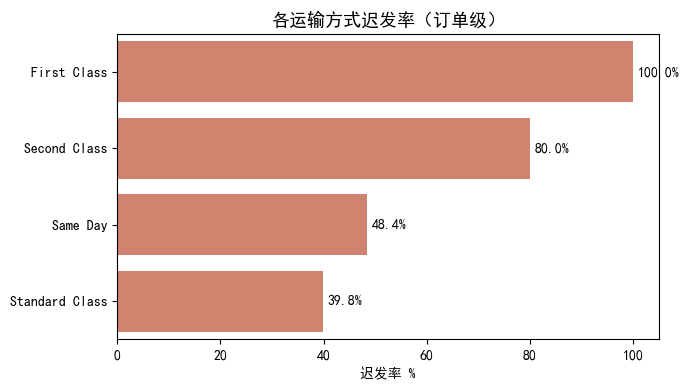

In [3]:
# 按运输方式分组，对 0/1 列求平均 = 各组迟发率
by_mode = (orders.groupby('shipping_mode')['late_delivery_risk']
                 .mean().mul(100).round(1)
                 .sort_values(ascending=False).reset_index())
by_mode.columns = ['shipping_mode', 'late_rate']
print(by_mode)

# 画横向条形图
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=by_mode, x='late_rate', y='shipping_mode', color='#e07a5f')
for i, v in enumerate(by_mode['late_rate']):          # 在条形末端标数值
    ax.text(v + 1, i, f'{v}%', va='center')
plt.title('各运输方式迟发率（订单级）', fontsize=13)
plt.xlabel('迟发率 %'); plt.ylabel('')
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '各运输方式迟发率（订单级）.png', dpi=200, bbox_inches='tight')
plt.show()

## 分析结果1：不同运输等级的订单级迟发率存在显著差异

                承诺天   实际天    迟发率
shipping_mode                   
Same Day        0.0  0.48   48.4
First Class     1.0  2.00  100.0
Second Class    2.0  4.00   80.0
Standard Class  4.0  3.99   39.8


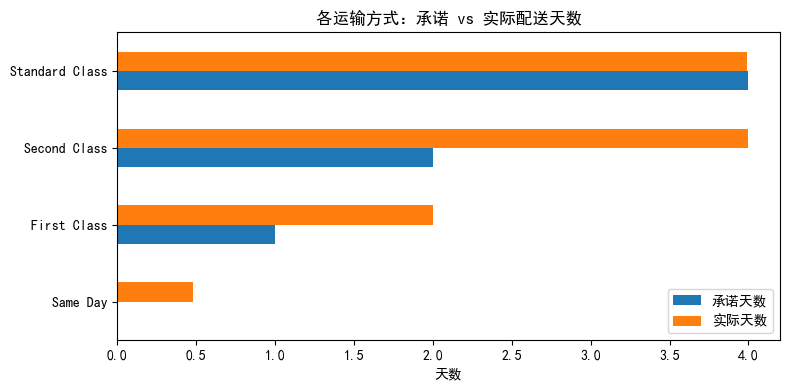

In [4]:
# 各运输等级的承诺配送天数与实际配送天数（订单级）
cmp = (orders.groupby('shipping_mode')
              .agg(承诺天=('days_for_shipment_scheduled', 'mean'),
                   实际天=('days_for_shipping_real', 'mean'),
                   迟发率=('late_delivery_risk', 'mean')))
cmp['迟发率'] = (cmp['迟发率'] * 100).round(1)   # 先乘100再round：0.4838→48.4%（若先round(2)会变成48.0%）
cmp[['承诺天', '实际天']] = cmp[['承诺天', '实际天']].round(2)
cmp = cmp.sort_values('承诺天')
print(cmp)

cmp[['承诺天', '实际天']].plot(kind='barh', figsize=(8, 4))
plt.title('各运输方式：承诺 vs 实际配送天数')
plt.xlabel('天数'); plt.ylabel(''); plt.legend(['承诺天数', '实际天数'])
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '各运输方式：承诺vs实际配送天数.png', dpi=200, bbox_inches='tight')
plt.show()

## 分析结果2：部分运输等级的承诺天数低于实际配送能力

         market  late_rate
0  Pacific Asia       57.7
1          USCA       57.5
2        Europe       57.4
3         LATAM       56.9
4        Africa       56.5


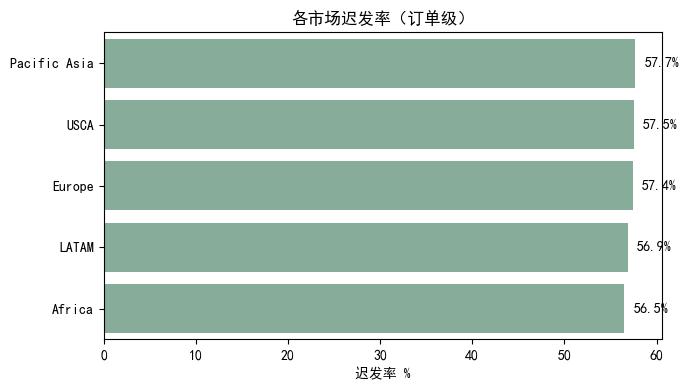

In [5]:
# Cell 5：按市场的迟发率（就是 Cell 3 把 'shipping_mode' 换成 'market'）
by_market = (orders.groupby('market')['late_delivery_risk']
                   .mean().mul(100).round(1)
                   .sort_values(ascending=False).reset_index())
by_market.columns = ['market', 'late_rate']
print(by_market)

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=by_market, x='late_rate', y='market', color='#81b29a')
for i, v in enumerate(by_market['late_rate']):
    ax.text(v + 1, i, f'{v}%', va='center')
plt.title('各市场迟发率（订单级）'); plt.xlabel('迟发率 %'); plt.ylabel('')
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '各市场迟发率（订单级）.png', dpi=200, bbox_inches='tight')
plt.show()

## 分析结果3：各市场订单级迟发率差异较小

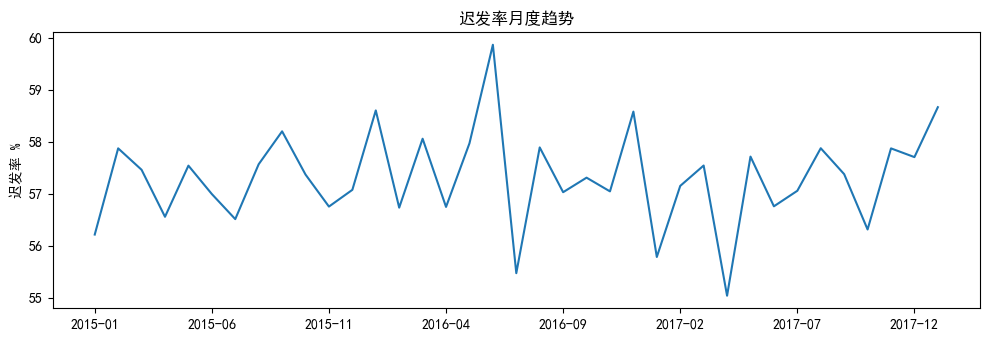

In [6]:
# 按月迟发率趋势
orders = orders.copy()
orders['ym'] = pd.to_datetime(orders['order_date_key']).dt.to_period('M').astype(str)
trend = orders.groupby('ym')['late_delivery_risk'].mean().mul(100)

plt.figure(figsize=(10, 3.5))
trend.plot()
plt.title('迟发率月度趋势'); plt.ylabel('迟发率 %'); plt.xlabel('')
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '迟发率月度趋势.png', dpi=200, bbox_inches='tight')
plt.show()

## 分析结果4：订单级迟发率在时间维度保持稳定

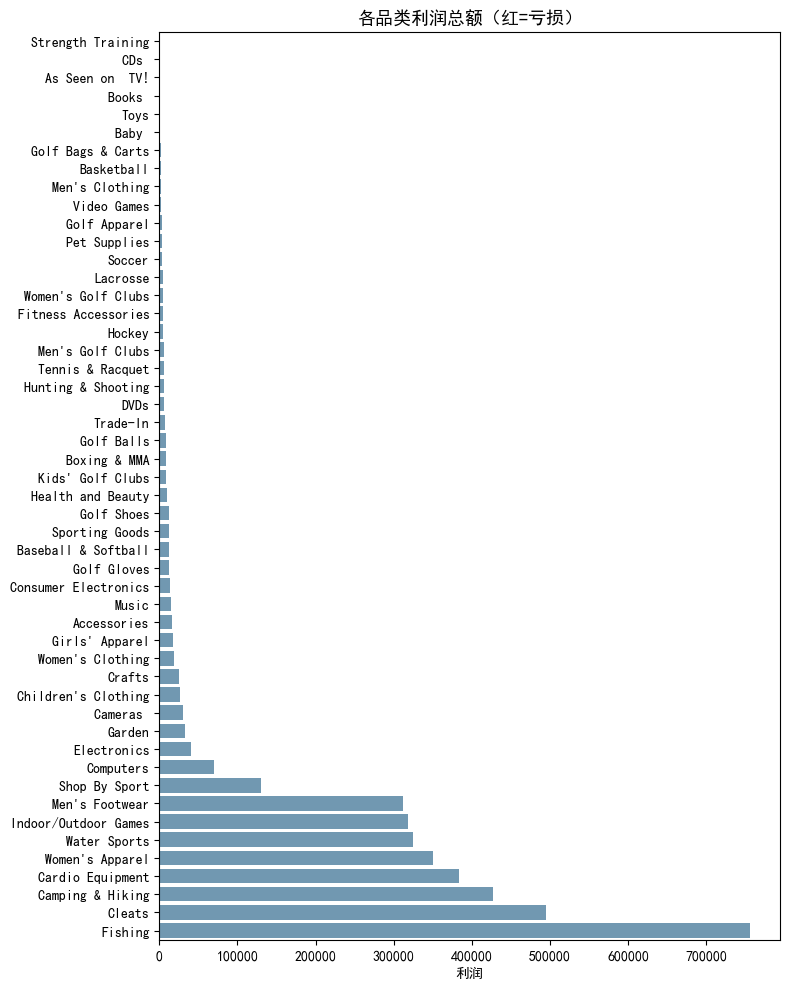

In [7]:
# 各品类订单行利润汇总
cat_profit = (df.groupby('category_name')['order_profit_per_order']
                .sum().sort_values().reset_index())
cat_profit.columns = ['category', 'profit']

plt.figure(figsize=(8, 10))
colors = ['#c1121f' if v < 0 else '#669bbc' for v in cat_profit['profit']]  # 亏损标红
sns.barplot(data=cat_profit, x='profit', y='category', palette=colors, hue='category', legend=False)
plt.title('各品类利润总额（红=亏损）', fontsize=13)
plt.xlabel('利润'); plt.ylabel('')
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '各品类利润总额.png', dpi=200, bbox_inches='tight')
plt.show()

In [8]:
# 发现5 的量化支撑：把利润 SUM 到 品类×区域 格子级 / SKU 级，数一数有几个净亏
cell_net = df.groupby(['category_name', 'order_region'])['order_profit_per_order'].sum()
neg_cells = cell_net[cell_net < 0]
total_loss = df.loc[df['order_profit_per_order'] < 0, 'order_profit_per_order'].sum()
print(f"品类×区域 格子数: {len(cell_net)} | 净亏格子: {len(neg_cells)} 个")
print(f"净亏格子合计: {neg_cells.sum()/1e4:.2f} 万，仅占总亏损({total_loss/1e4:.0f}万)的 {neg_cells.sum()/total_loss*100:.1f}%")
sku_net = df.groupby('product_name')['order_profit_per_order'].sum()
print(f"SKU 级净亏: {(sku_net < 0).sum()} / {len(sku_net)} 个")
print("→ 聚合净额切不出亏损区：亏损被同格子的盈利单抵消掉了，得换维度找")

品类×区域 格子数: 691 | 净亏格子: 60 个
净亏格子合计: -1.45 万，仅占总亏损(-388万)的 0.4%
SKU 级净亏: 3 / 118 个
→ 聚合净额切不出亏损区：亏损被同格子的盈利单抵消掉了，得换维度找


## 分析结果5：品类与区域汇总净亏仅占全部亏损的0.4%

                   行数        合计亏  占总亏损%
深度                                     
超深亏(<=-100%)     6301 -2062101.0   53.1
深亏(-100%~-50%)   9394 -1248701.0   32.2
中亏(-50%~-20%)    8014  -398808.0   10.3
浅亏(-20%~0)      10075  -173937.0    4.5

深亏+超深亏(<-50%): 15695 行 = 总订单行的 8.69%，亏 -331 万（占总亏损 85.3%）


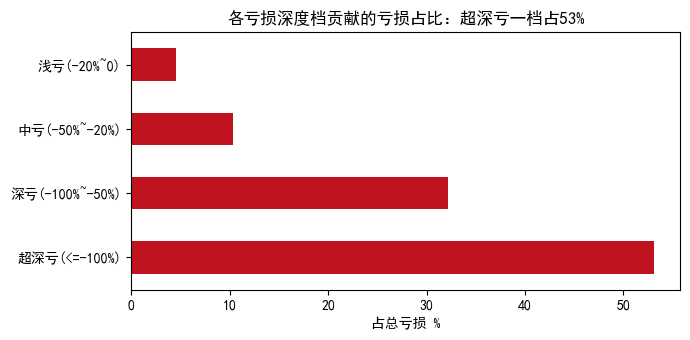

In [9]:
# 亏损不集中在品类/区域 → 换"深度"维度：按行级利润率给亏损单分档
# 边界归属与 Power BI 计算列保持一致：
#   超深亏 ratio<=-100% ｜ 深亏 (-100%,-50%) ｜ 中亏 [-50%,-20%) ｜ 浅亏 [-20%,0)
#   利润率等于 -50% 的 108 个订单行归入中度亏损
import numpy as np
loss = df[df['order_profit_per_order'] < 0].copy()
ratio = loss['order_item_profit_ratio']
labels = ['超深亏(<=-100%)', '深亏(-100%~-50%)', '中亏(-50%~-20%)', '浅亏(-20%~0)']
loss['深度'] = np.select([ratio <= -1.0, ratio < -0.5, ratio < -0.2],
                        labels[:3], default=labels[3])

depth = (loss.groupby('深度')
             .agg(行数=('order_profit_per_order', 'size'),
                  合计亏=('order_profit_per_order', 'sum'))
             .reindex(labels).round(0))
depth['占总亏损%'] = (depth['合计亏'] / loss['order_profit_per_order'].sum() * 100).round(1)
print(depth)
n_deep = (ratio < -0.5).sum()
print(f"\n深亏+超深亏(<-50%): {n_deep} 行 = 总订单行的 {n_deep/len(df)*100:.2f}%"
      f"，亏 {loss.loc[ratio < -0.5, 'order_profit_per_order'].sum()/1e4:.0f} 万"
      f"（占总亏损 {loss.loc[ratio < -0.5, 'order_profit_per_order'].sum()/loss['order_profit_per_order'].sum()*100:.1f}%）")

depth['占总亏损%'].plot(kind='barh', figsize=(7, 3.5), color='#c1121f')
plt.title('各亏损深度档贡献的亏损占比：超深亏一档占53%')
plt.xlabel('占总亏损 %'); plt.ylabel('')
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '各亏损深度档贡献的亏损占比.png', dpi=200, bbox_inches='tight')
plt.show()

## 分析结果6：8.69%的深亏订单行贡献85.3%的亏损

   阈值  拦截行占比%  覆盖亏损%
 -20%   13.13   95.5
 -30%   10.01   89.5
 -40%    9.34   87.6
 -50%    8.69   85.3
 -60%    8.35   83.6
 -80%    4.81   62.3
-100%    3.49   53.1


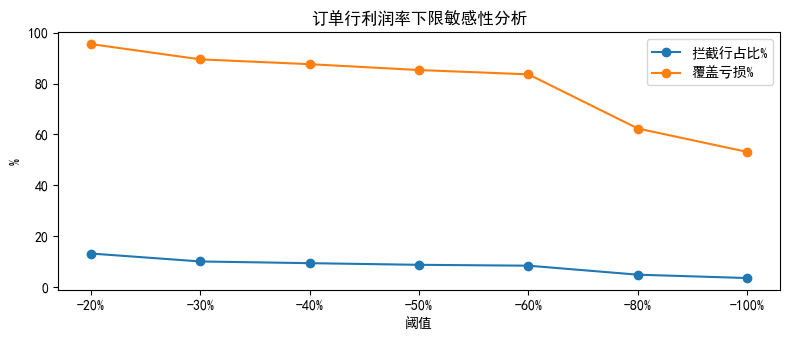

In [10]:
# margin floor 阈值敏感性：拦截线画在哪？逐档算"拦截多少订单行"与"覆盖多少亏损"
# 阈值口径与 Power BI 盈利结构页面一致：ratio 严格小于阈值
sens = []
for t in [-0.2, -0.3, -0.4, -0.5, -0.6, -0.8, -1.0]:
    hit = df['order_item_profit_ratio'] < t
    sens.append({'阈值': f'{t*100:.0f}%',
                 '拦截行占比%': round(hit.mean() * 100, 2),
                 '覆盖亏损%': round(df.loc[hit, 'order_profit_per_order'].sum() / total_loss * 100, 1)})
sens = pd.DataFrame(sens)
print(sens.to_string(index=False))

sens.plot(x='阈值', y=['拦截行占比%', '覆盖亏损%'], kind='line', marker='o', figsize=(8, 3.5))
plt.title('订单行利润率下限敏感性分析')
plt.ylabel('%'); plt.tight_layout()
plt.savefig(DASHBOARD_DIR / 'margin floor敏感性.png', dpi=200, bbox_inches='tight')
plt.show()

## 分析结果6b：-50%阈值覆盖85%的亏损并控制审核订单行范围

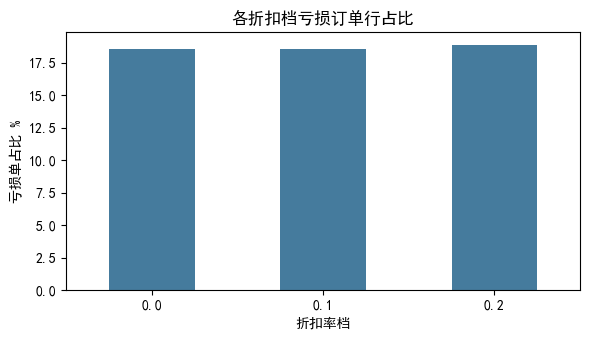

In [11]:
disc = (df.assign(亏损=(df['order_profit_per_order'] < 0).astype(int),
                  折扣档=df['order_item_discount_rate'].round(1))
          .groupby('折扣档')['亏损'].mean().mul(100).round(1))

disc.plot(kind='bar', figsize=(6, 3.5), color='#457b9d', rot=0)
plt.title('各折扣档亏损订单行占比')
plt.ylabel('亏损单占比 %'); plt.xlabel('折扣率档')
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / '各折扣档亏损单占比.png', dpi=200, bbox_inches='tight')
plt.show()

## 分析结果7：各折扣档亏损订单行占比均约18.7%

## 综合分析结论

| 分析主题 | 量化结果 | 业务含义 |
|---|---|---|
| 运输等级 | First Class 100%、Second Class 80%、Same Day 48%、Standard Class 40% | 订单级迟发率与运输等级的承诺时效相关 |
| 承诺与实际 | First Class 1天/2天，Second Class 2天/4天，Standard Class 4天/3.99天 | First Class 和 Second Class 存在承诺时效与实际能力偏差 |
| 市场与时间 | 市场差异1.2个百分点，月度迟发率基本稳定 | 迟发不集中于单一市场或短期时段 |
| 品类与区域 | 691个组合中60个净亏，合计占全部亏损0.4% | 汇总净额不能充分反映行级亏损 |
| 亏损深度 | 利润率低于-50%的订单行占8.69%，贡献85.3%的亏损 | 利润率下限适合用于识别高影响亏损订单行 |
| 折扣档 | 各折扣档亏损订单行占比约18.6%至18.9% | 亏损覆盖率在折扣档之间差异较小 |

盈利分析建议设置分级利润率下限；履约分析建议分别实施并评估承诺时效校准与运输能力改善。